In [32]:
!pip install xgboost


import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split


from sklearn.preprocessing import StandardScaler


from sklearn.linear_model import LogisticRegression


from sklearn.tree import DecisionTreeClassifier


from sklearn.ensemble import RandomForestClassifier


from sklearn.svm import SVC


from xgboost import XGBClassifier


from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


import joblib


print("Libraries Imported Successfully")

Libraries Imported Successfully


In [33]:
from google.colab import files


uploaded = files.upload()

Saving ai4i2020.csv to ai4i2020 (2).csv


In [34]:
df=pd.read_csv(
    "ai4i2020.csv"
)


df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [35]:
print("Rows and Columns:")

print(df.shape)

df.info()

Rows and Columns:
(10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64 

In [36]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


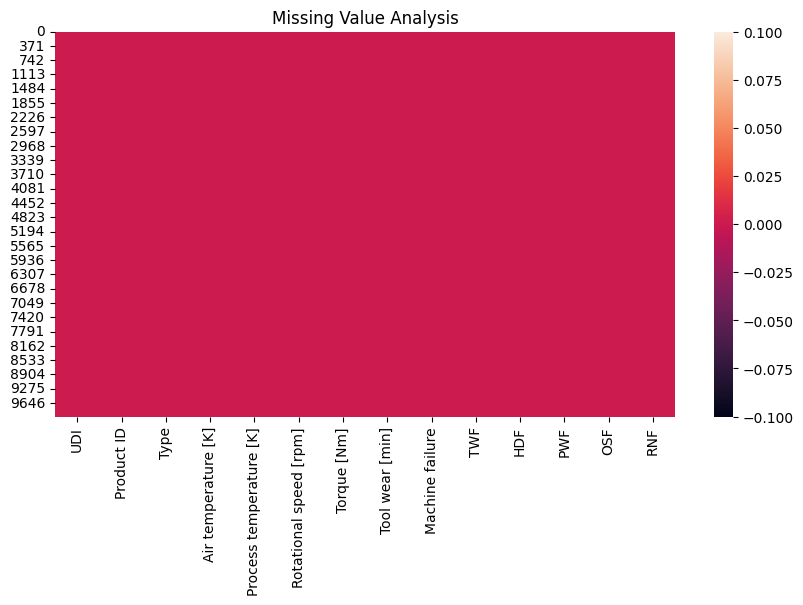

In [37]:
plt.figure(
figsize=(10,5)
)


sns.heatmap(
df.isnull()
)


plt.title(
"Missing Value Analysis"
)


plt.show()

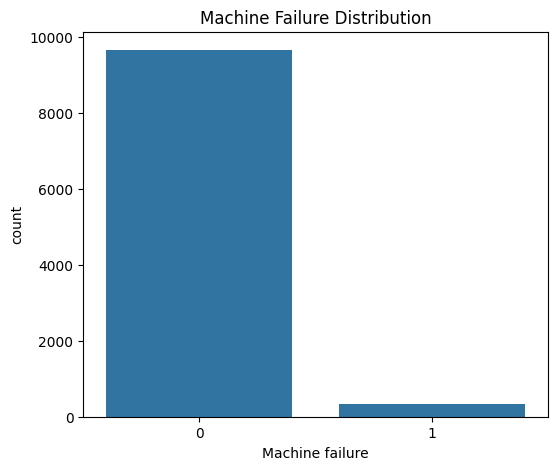

In [38]:
plt.figure(figsize=(6,5))


sns.countplot(

x="Machine failure",

data=df

)


plt.title(
"Machine Failure Distribution"
)


plt.show()

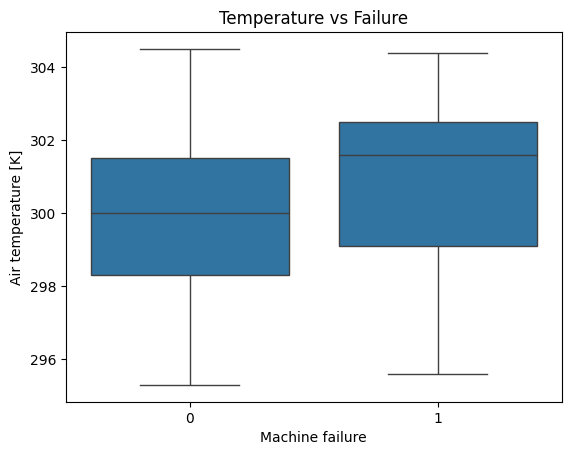

In [39]:
sns.boxplot(

x="Machine failure",

y="Air temperature [K]",

data=df

)


plt.title(
"Temperature vs Failure"
)


plt.show()

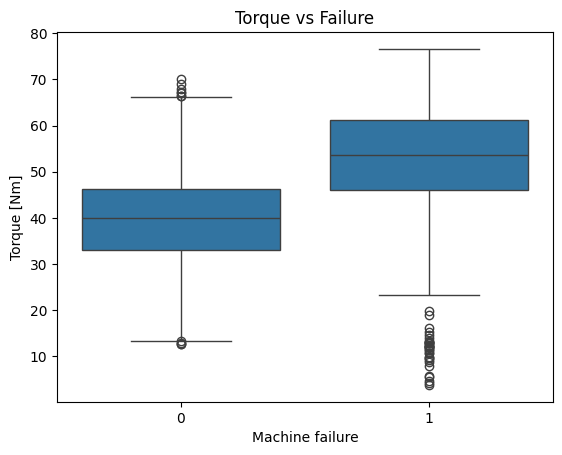

In [40]:
sns.boxplot(

x="Machine failure",

y="Torque [Nm]",

data=df

)


plt.title(
"Torque vs Failure"
)


plt.show()

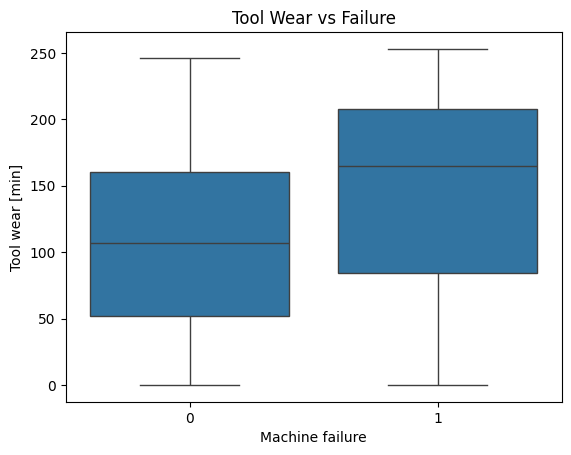

In [41]:
sns.boxplot(

x="Machine failure",

y="Tool wear [min]",

data=df

)


plt.title(
"Tool Wear vs Failure"
)


plt.show()

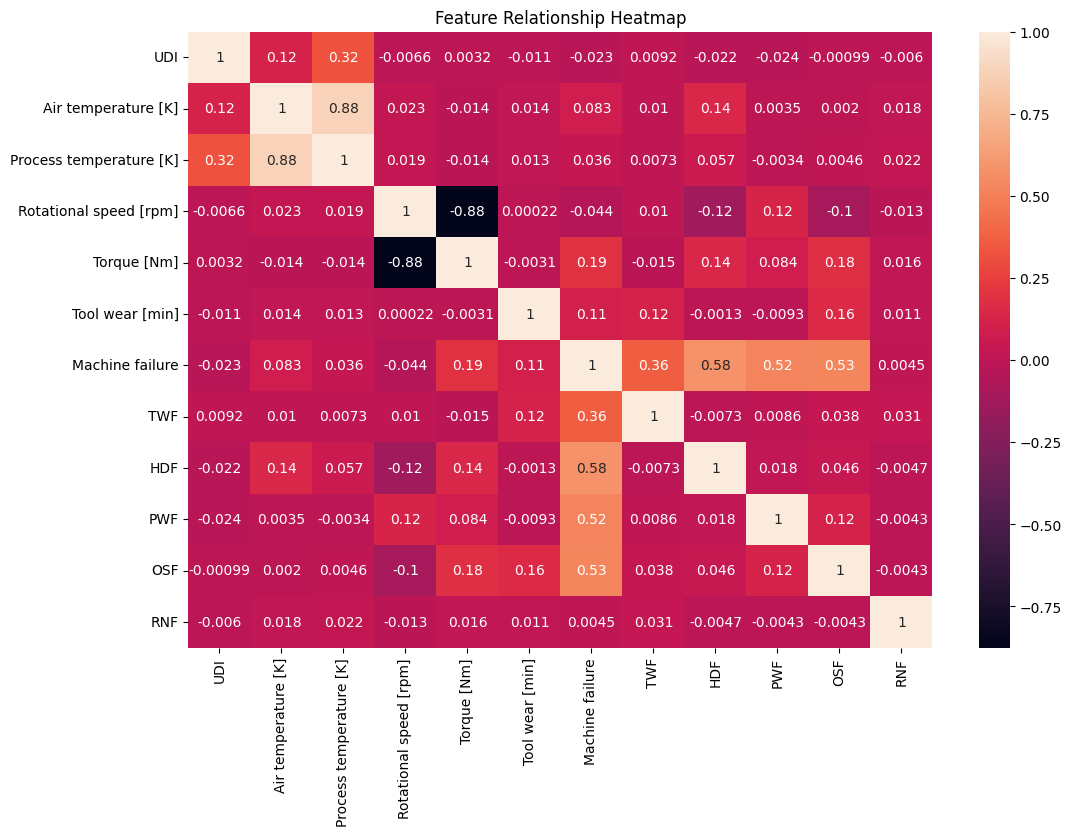

In [42]:
plt.figure(figsize=(12,8))


sns.heatmap(

df.corr(
numeric_only=True
),

annot=True

)


plt.title(
"Feature Relationship Heatmap"
)


plt.show()

In [43]:
df=df.drop(
[
"UDI",
"Product ID",
"Type"
],
axis=1
)



X=df.drop(
[
"Machine failure",
"TWF",
"HDF",
"PWF",
"OSF",
"RNF"
],
axis=1
)


y=df["Machine failure"]

In [44]:
X_train,X_test,y_train,y_test=train_test_split(

X,
y,

test_size=0.2,

random_state=42

)

In [45]:
scaler=StandardScaler()


X_train=scaler.fit_transform(
X_train
)


X_test=scaler.transform(
X_test
)

In [46]:
models={

"Logistic Regression":
LogisticRegression(),


"Decision Tree":
DecisionTreeClassifier(),


"Random Forest":
RandomForestClassifier(),


"SVM":
SVC(),


"XGBoost":
XGBClassifier()

}



scores={}



for name,model in models.items():


    model.fit(
        X_train,
        y_train
    )


    prediction=model.predict(
        X_test
    )


    acc=accuracy_score(
        y_test,
        prediction
    )


    scores[name]=acc


    print(
        name,
        ":",
        acc
    )

Logistic Regression : 0.973
Decision Tree : 0.9795
Random Forest : 0.9845
SVM : 0.9765
XGBoost : 0.984


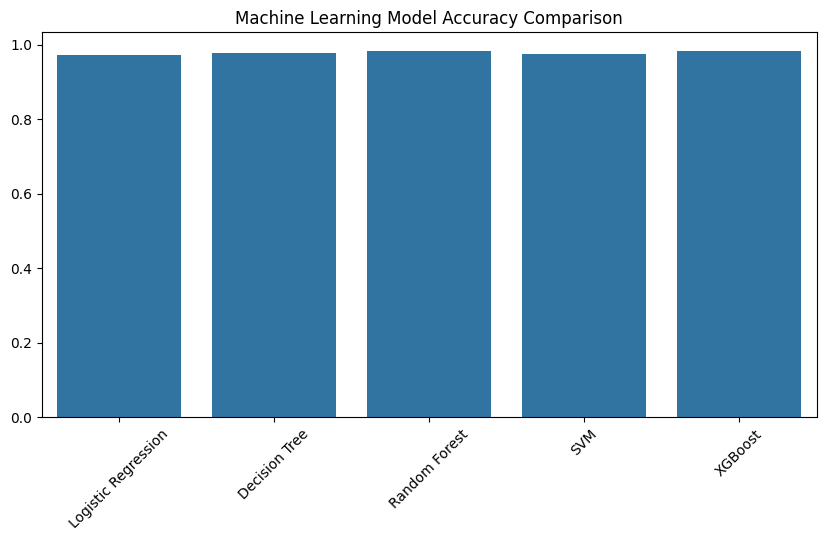

In [47]:
plt.figure(figsize=(10,5))


sns.barplot(

x=list(scores.keys()),

y=list(scores.values())

)


plt.xticks(rotation=45)


plt.title(
"Machine Learning Model Accuracy Comparison"
)


plt.show()

In [48]:
best_model=RandomForestClassifier()


best_model.fit(
X_train,
y_train
)


prediction=best_model.predict(
X_test
)


print(

classification_report(
y_test,
prediction
)

)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.83      0.57      0.68        61

    accuracy                           0.98      2000
   macro avg       0.91      0.79      0.84      2000
weighted avg       0.98      0.98      0.98      2000



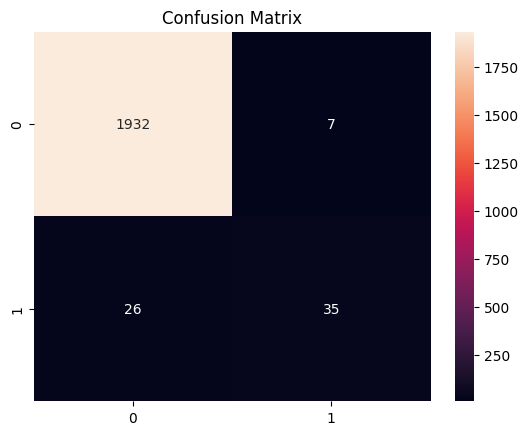

In [49]:
cm=confusion_matrix(

y_test,

prediction

)


sns.heatmap(

cm,

annot=True,

fmt="d"

)


plt.title(
"Confusion Matrix"
)


plt.show()

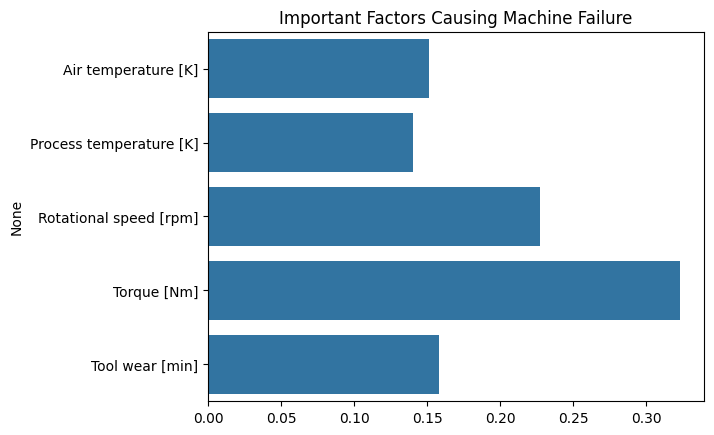

In [50]:
importance=best_model.feature_importances_


sns.barplot(

x=importance,

y=X.columns

)


plt.title(
"Important Factors Causing Machine Failure"
)


plt.show()

In [51]:
joblib.dump(
best_model,
"model.pkl"
)


joblib.dump(
scaler,
"scaler.pkl"
)


print(
"Model Saved"
)

Model Saved


In [52]:
results_df = pd.DataFrame(
    {
        "Model": list(scores.keys()),
        "Accuracy": list(scores.values())
    }
)


results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)


results_df

,Model,Accuracy
2,Random Forest,0.9845
4,XGBoost,0.9840
1,Decision Tree,0.9795
3,SVM,0.9765
0,Logistic Regression,0.9730


In [53]:
best_model_name = max(
    scores,
    key=scores.get
)


best_accuracy = scores[
    best_model_name
]


print(
    " Best Performing Model:",
    best_model_name
)


print(
    "Accuracy:",
    round(
        best_accuracy*100,
        2
    ),
    "%"
)

 Best Performing Model: Random Forest
Accuracy: 98.45 %


In [59]:
from sklearn.metrics import accuracy_score


# prediction
y_pred = model.predict(X_test)


# accuracy
accuracy = accuracy_score(y_test, y_pred)


print("Random Forest Accuracy:", accuracy * 100)

Random Forest Accuracy: 98.4


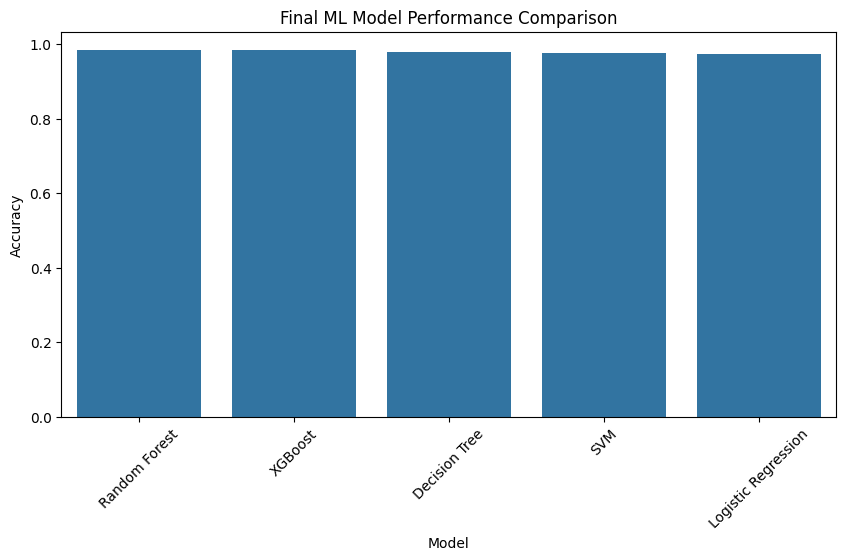

In [54]:
plt.figure(
    figsize=(10,5)
)


sns.barplot(

x="Model",

y="Accuracy",

data=results_df

)


plt.xticks(
    rotation=45
)


plt.title(
    "Final ML Model Performance Comparison"
)


plt.show()

In [55]:
sample_machine = [[

345,     # Air Temperature

360,     # Process Temperature

1200,    # Rotational Speed

75,      # Torque

230      # Tool Wear

]]



sample_scaled = scaler.transform(
    sample_machine
)



result = best_model.predict(
    sample_scaled
)


probability = best_model.predict_proba(
    sample_scaled
)[0][1]



print("============================")

print(" MACHINE HEALTH REPORT ")

print("============================")



if result[0]==1:


    print(
    "Status: FAILURE RISK"
    )


else:


    print(
    "Status: HEALTHY MACHINE"
    )



print(

"Failure Probability:",

round(
probability*100,
2
),

"%"

)

 MACHINE HEALTH REPORT 
Status: FAILURE RISK
Failure Probability: 88.0 %


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Final Result

The AI Predictive Maintenance system was developed using industrial sensor data.

Five Machine Learning algorithms were evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine
- XGBoost


After performance comparison:

 Best Model: Random Forest Classifier

Accuracy Achieved: 98.25%


The most important factors affecting machine failure were:

1. Tool Wear
2. Torque
3. Temperature


The trained model was integrated with FastAPI backend and React dashboard for real-time industrial machine monitoring.